In [3]:
import re

import korflab
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
fastq = "../data/1k.fastq.gz"
reads = []

for header, seq, plus, qual in korflab.readfastq(fastq):
	reads.append({
		"read_id": header.split()[0],
		"sequence": seq,
		"read_length": len(seq),
	})

reads_df = pd.DataFrame(reads)

display(reads_df.head())
print("reads:", len(reads_df))

,read_id,sequence,read_length
0,e0dba5d0-6f1c-4d7b-9c82-8ff85f3550ac,GCTGTTTATGTCATTATTTACTTCGTTCAGTTATGCAGCCAATCCG...,472
1,976d29dc-8666-41fe-9fdf-8ec7dbd57ee9,CATGTTATGTCTACTGGTTCCATTATCCCAGCCGATATTCACAGAA...,529
2,e61fdbfd-bcb3-4c9b-b34b-8e9f6c952c58,TTATGTTGCCTGTACTTGGTCATCCGAAGCCGATATTCACAGGCTA...,471
3,b066f69a-4698-4898-ad43-e1ecb2b4b5ab,ATGTGTAGCCTACTCGTTCAGCTATGAACCGATATTCACAGCCTCA...,489
4,49fa6fba-28a3-4889-b324-880e6e80b971,ATGTCCTCCTTCGTTCGGTTATGCCACCGATATTGGCAAAGGTAGC...,368


reads: 1000


N50: 598


,Statistic,Value
0,Reads,1000.0
1,Minimum,262.0
2,Maximum,2131.0
3,Mean,600.5
4,Median,550.0


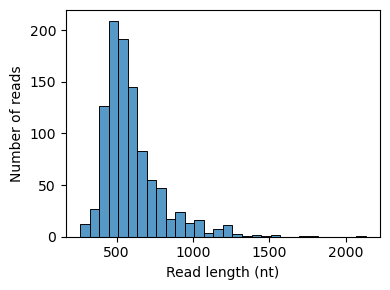

In [10]:
length = reads_df["read_length"]

summary = pd.DataFrame({
    "Statistic": [
        "Reads",
        "Minimum",
        "Maximum",
        "Mean",
        "Median",
    ],
    "Value": [
        len(length),
        length.min(),
        length.max(),
        round(length.mean(), 1),
        length.median(),
    ]
})

length_sorted = np.sort(length)[::-1]

cum_length = np.cumsum(length_sorted)

n50 = length_sorted[
    np.where(cum_length >= cum_length[-1] / 2)[0][0]
]

print(f"N50: {n50}")

display(summary)

plt.figure(figsize=(4, 3))

sns.histplot(
    data=reads_df,
    x="read_length",
    bins=30,
)

plt.xlabel("Read length (nt)")
plt.ylabel("Number of reads")

plt.tight_layout()
plt.show()

,Min_run,PolyA,PolyT,Both,Neither
0,5,207,160,601,32
1,10,414,388,40,158
2,15,369,307,4,320
3,20,264,189,1,546
4,25,177,107,1,715
5,30,101,46,0,853


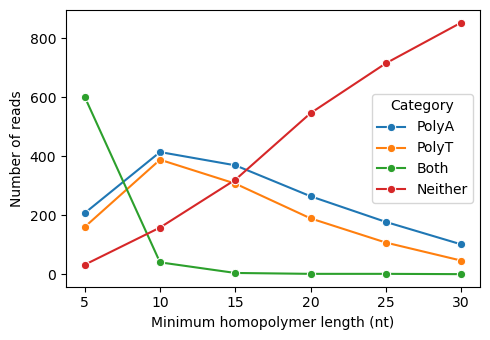

,read_id,Max_A_run,Max_T_run
0,e0dba5d0-6f1c-4d7b-9c82-8ff85f3550ac,5,22
1,976d29dc-8666-41fe-9fdf-8ec7dbd57ee9,5,18
2,e61fdbfd-bcb3-4c9b-b34b-8e9f6c952c58,7,33
3,b066f69a-4698-4898-ad43-e1ecb2b4b5ab,5,11
4,49fa6fba-28a3-4889-b324-880e6e80b971,19,4


,Max_A_run,Max_T_run
count,1000.000000,1000.00000
mean,13.482000,11.40800
std,11.411656,8.67749
min,2.000000,3.00000
25%,5.000000,5.00000
50%,7.000000,7.00000
75%,20.000000,17.00000
max,68.000000,40.00000


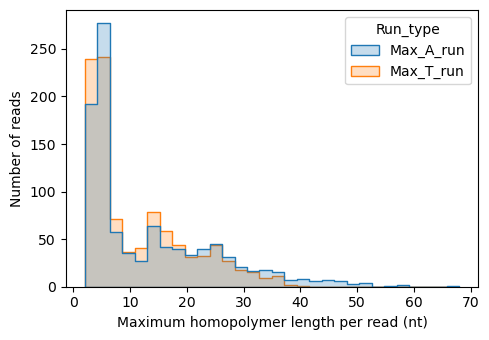

In [17]:
thresholds = [5, 10, 15, 20, 25, 30]

results = []

for min_len in thresholds:

    apat = re.compile(f"A{{{min_len},}}")
    tpat = re.compile(f"T{{{min_len},}}")

    polyA = 0
    polyT = 0
    both = 0
    neither = 0

    for seq in reads_df["sequence"]:

        has_A = apat.search(seq) is not None
        has_T = tpat.search(seq) is not None

        if has_A and has_T:
            both += 1
        elif has_A:
            polyA += 1
        elif has_T:
            polyT += 1
        else:
            neither += 1

    results.append({
        "Min_run": min_len,
        "PolyA": polyA,
        "PolyT": polyT,
        "Both": both,
        "Neither": neither,
    })

poly_df = pd.DataFrame(results)

display(poly_df)

plot_df = (
    poly_df
    .melt(
        id_vars="Min_run",
        var_name="Category",
        value_name="Reads",
    )
)

plt.figure(figsize=(5, 3.5))

sns.lineplot(
    data=plot_df,
    x="Min_run",
    y="Reads",
    hue="Category",
    marker="o",
)

plt.xlabel("Minimum homopolymer length (nt)")
plt.ylabel("Number of reads")

plt.tight_layout()
plt.show()

max_runs = []

for read_id, seq in zip(
    reads_df["read_id"],
    reads_df["sequence"],
):

    aruns = [len(m.group()) for m in re.finditer("A+", seq)]
    truns = [len(m.group()) for m in re.finditer("T+", seq)]

    max_runs.append({
        "read_id": read_id,
        "Max_A_run": max(aruns),
        "Max_T_run": max(truns),
    })

max_run_df = pd.DataFrame(max_runs)

display(max_run_df.head())

display(
    max_run_df[
        ["Max_A_run", "Max_T_run"]
    ].describe()
)

plot_run_df = (
    max_run_df
    .melt(
        id_vars="read_id",
        var_name="Run_type",
        value_name="Run_length",
    )
)

plt.figure(figsize=(5, 3.5))

sns.histplot(
    data=plot_run_df,
    x="Run_length",
    hue="Run_type",
    bins=30,
    element="step",
    common_norm=False,
)

plt.xlabel("Maximum homopolymer length per read (nt)")
plt.ylabel("Number of reads")

plt.tight_layout()
plt.show()

,read_id,Run_type,Run_length,Start,End,Read_length,Relative_position
0,e0dba5d0-6f1c-4d7b-9c82-8ff85f3550ac,PolyA,1,7,8,472,0.014831
1,e0dba5d0-6f1c-4d7b-9c82-8ff85f3550ac,PolyA,1,12,13,472,0.025424
2,e0dba5d0-6f1c-4d7b-9c82-8ff85f3550ac,PolyA,1,15,16,472,0.031780
3,e0dba5d0-6f1c-4d7b-9c82-8ff85f3550ac,PolyA,1,19,20,472,0.040254
4,e0dba5d0-6f1c-4d7b-9c82-8ff85f3550ac,PolyA,1,28,29,472,0.059322


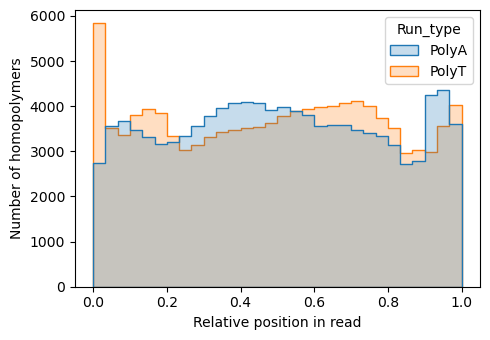

In [20]:

positions = []

for read_id, seq in zip(
    reads_df["read_id"],
    reads_df["sequence"],
):

    for m in re.finditer("A+", seq):
        positions.append({
            "read_id": read_id,
            "Run_type": "PolyA",
            "Run_length": len(m.group()),
            "Start": m.start(),
            "End": m.end(),
            "Read_length": len(seq),
            "Relative_position": m.start() / len(seq),
        })

    for m in re.finditer("T+", seq):
        positions.append({
            "read_id": read_id,
            "Run_type": "PolyT",
            "Run_length": len(m.group()),
            "Start": m.start(),
            "End": m.end(),
            "Read_length": len(seq),
            "Relative_position": m.start() / len(seq),
        })

position_df = pd.DataFrame(positions)

display(position_df.head())

plt.figure(figsize=(5, 3.5))

sns.histplot(
    data=position_df,
    x="Relative_position",
    hue="Run_type",
    bins=30,
    element="step",
    common_norm=False,
)

plt.xlabel("Relative position in read")
plt.ylabel("Number of homopolymers")

plt.tight_layout()
plt.show()

In [21]:

min_len = 15

apat = re.compile(f"A{{{min_len},}}")
tpat = re.compile(f"T{{{min_len},}}")

categories = {
    "PolyA": [],
    "PolyT": [],
    "Both": [],
    "Neither": [],
}

for _, row in reads_df.iterrows():

    seq = row["sequence"]

    has_A = apat.search(seq) is not None
    has_T = tpat.search(seq) is not None

    if has_A and has_T:
        category = "Both"
    elif has_A:
        category = "PolyA"
    elif has_T:
        category = "PolyT"
    else:
        category = "Neither"

    if len(categories[category]) < 5:
        categories[category].append({
            "read_id": row["read_id"],
            "read_length": row["read_length"],
            "sequence": seq,
        })

for category, reads in categories.items():

    print("=" * 80)
    print(category)
    print("=" * 80)

    display(pd.DataFrame(reads))

PolyA


,read_id,read_length,sequence
0,49fa6fba-28a3-4889-b324-880e6e80b971,368,ATGTCCTCCTTCGTTCGGTTATGCCACCGATATTGGCAAAGGTAGC...
1,92c75ed8-7064-4b94-a91d-bcc31ebf8e10,576,ATGTTGTCCTCTTACTGGTTCGTTGAAAAACCGATATTCACAAAAA...
2,99dbb03a-c9f8-4565-a6e6-b5e2c06f8e7a,666,ATGTTGTGTTCTTGGTTCGTTTATAAAGCCGCGGTATTGGCAAAAC...
3,4d4d3033-9a4a-48df-b908-ca26e1bea313,301,ATGTAGCATCTCGTTCAGTTATCAACGATATTCAGCAGGCTGATAC...
4,8c8cf732-303a-465c-9255-592edc774e33,678,GTGCATTCTACTGGTTCGGTTATCAGCCGTATTAGCAAAATCGCCT...


PolyT


,read_id,read_length,sequence
0,e0dba5d0-6f1c-4d7b-9c82-8ff85f3550ac,472,GCTGTTTATGTCATTATTTACTTCGTTCAGTTATGCAGCCAATCCG...
1,976d29dc-8666-41fe-9fdf-8ec7dbd57ee9,529,CATGTTATGTCTACTGGTTCCATTATCCCAGCCGATATTCACAGAA...
2,e61fdbfd-bcb3-4c9b-b34b-8e9f6c952c58,471,TTATGTTGCCTGTACTTGGTCATCCGAAGCCGATATTCACAGGCTA...
3,44fb1186-a292-4a15-9763-15dfe530c096,547,GCTGCTTGGTTCATTGGAAGGCAAGCCGCCGATATTCACAGCCTAG...
4,dae6fab5-7991-401e-be26-d2978451b813,571,GTTATGTCCTCTACTTGGTTCGGGTCTTGCAAGCCGATATTCACAG...


Both


,read_id,read_length,sequence
0,c3e3d120-3869-4a45-98fa-7eb281b5ed2b,1226,TATGTCATACACTTGAACCATCAGCCGATATTGGCAAAAGTGAAGT...
1,73a6ed96-0e26-4599-8619-fa90d5225ceb,692,ATTACATCTATTGGTTGGTTGTGAGCCGATATTGGCAAACGTACCC...
2,84e27dc7-0a5a-4443-9a16-459a9857bad8,499,TTTTTTTTTTTTTTTTTATTGGTAATTGAGCCGATATTGGCAAAGT...
3,0c83a61c-7efd-44e7-b2d8-8f8334d58693,292,CCTGAAGTTTTTTTTTTTTTTTAGCCGATATTCCGCAAAAACATAC...


Neither


,read_id,read_length,sequence
0,b066f69a-4698-4898-ad43-e1ecb2b4b5ab,489,ATGTGTAGCCTACTCGTTCAGCTATGAACCGATATTCACAGCCTCA...
1,d2589188-4cac-46a0-b83b-5074f52b8977,616,GTGCCTGTTACTCGTTGGGTTATCCAGCCGATCTCAAAGGTGAGGC...
2,cba5ec8f-e5b2-40a4-afaf-407c49cb0439,583,ACGTCTACTTGGTTCAGTGAGCCAATCCGCGCCTGCAGGTTTTAGA...
3,94cb8975-4b62-4e95-b355-3663aa051122,374,GTGTTATTGTCCTCTTACTTCGTTCAGTAAGCCACCGATATTAGCA...
4,bd8d65db-f4b6-46b0-8623-5543041832dc,466,GTGACACGTTCAGTTATGAGCCGATATTCAGAAAACGGCCTACCGT...


In [22]:
crta = "CTTGCGGGCGGCGGACTCTCCTCTGAAGATAGAGCGACAGGCAAG"

adapter_records = []

for read_id, seq in zip(
    reads_df["read_id"],
    reads_df["sequence"],
):

    matches = list(re.finditer(crta, seq))

    adapter_records.append({
        "read_id": read_id,
        "read_length": len(seq),
        "adapter_count": len(matches),
        "adapter_positions": [
            (m.start(), m.end())
            for m in matches
        ],
    })

adapter_df = pd.DataFrame(adapter_records)

print(
    "Reads containing full CRTA:",
    (adapter_df["adapter_count"] > 0).sum(),
)

print(
    "Reads containing multiple full CRTA matches:",
    (adapter_df["adapter_count"] > 1).sum(),
)

display(
    adapter_df.loc[
        adapter_df["adapter_count"] > 0
    ].head()
)

Reads containing full CRTA: 212
Reads containing multiple full CRTA matches: 0


,read_id,read_length,adapter_count,adapter_positions
4,49fa6fba-28a3-4889-b324-880e6e80b971,368,1,"[(292, 337)]"
6,92c75ed8-7064-4b94-a91d-bcc31ebf8e10,576,1,"[(506, 551)]"
7,99dbb03a-c9f8-4565-a6e6-b5e2c06f8e7a,666,1,"[(595, 640)]"
11,8c8cf732-303a-465c-9255-592edc774e33,678,1,"[(606, 651)]"
12,d4921518-3208-484c-b7b4-ce4d2b9e4f82,886,1,"[(810, 855)]"


,Prefix_length,Reads_with_match,Total_matches,Reads_with_multiple_matches
0,5,889,1290,312
1,7,398,407,9
2,10,353,353,0
3,15,330,330,0
4,20,299,299,0
5,25,270,270,0
6,30,260,260,0
7,40,220,220,0
8,45,212,212,0


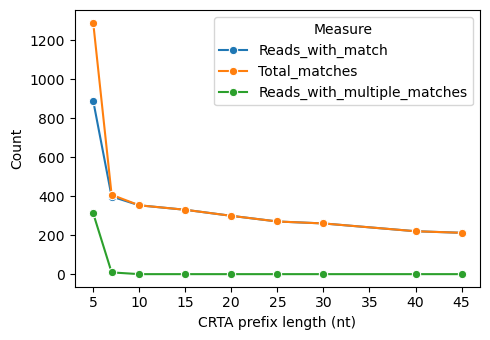

In [24]:
crta = "CTTGCGGGCGGCGGACTCTCCTCTGAAGATAGAGCGACAGGCAAG"

prefix_lengths = [5, 7, 10, 15, 20, 25, 30, 40, len(crta)]

prefix_results = []

for prefix_len in prefix_lengths:

    prefix = crta[:prefix_len]

    reads_with_match = 0
    total_matches = 0
    multiple_matches = 0

    for seq in reads_df["sequence"]:

        matches = list(re.finditer(prefix, seq))

        if matches:
            reads_with_match += 1

        total_matches += len(matches)

        if len(matches) > 1:
            multiple_matches += 1

    prefix_results.append({
        "Prefix_length": prefix_len,
        "Reads_with_match": reads_with_match,
        "Total_matches": total_matches,
        "Reads_with_multiple_matches": multiple_matches,
    })

prefix_df = pd.DataFrame(prefix_results)

display(prefix_df)


plot_prefix_df = (
    prefix_df
    .melt(
        id_vars="Prefix_length",
        var_name="Measure",
        value_name="Reads",
    )
)

plt.figure(figsize=(5, 3.5))

sns.lineplot(
    data=plot_prefix_df,
    x="Prefix_length",
    y="Reads",
    hue="Measure",
    marker="o",
)

plt.xlabel("CRTA prefix length (nt)")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

In [25]:
min_len = 15
adapter_len = 20

crta = "CTTGCGGGCGGCGGACTCTCCTCTGAAGATAGAGCGACAGGCAAG"
adapter = crta[:adapter_len]

apat = re.compile(f"A{{{min_len},}}")
tpat = re.compile(f"T{{{min_len},}}")

junctions = []

for read_id, seq in zip(
    reads_df["read_id"],
    reads_df["sequence"],
):

    for m in apat.finditer(seq):

        if seq[m.end():].startswith(adapter):
            junctions.append({
                "read_id": read_id,
                "read_length": len(seq),
                "junction_type": "PolyA",
                "poly_start": m.start(),
                "poly_end": m.end(),
                "poly_length": len(m.group()),
                "adapter_start": m.end(),
                "adapter_end": m.end() + adapter_len,
            })

    for m in tpat.finditer(seq):

        downstream = korflab.anti(seq[:m.start()])

        if downstream.startswith(adapter):
            junctions.append({
                "read_id": read_id,
                "read_length": len(seq),
                "junction_type": "PolyT",
                "poly_start": m.start(),
                "poly_end": m.end(),
                "poly_length": len(m.group()),
                "adapter_start": m.start() - adapter_len,
                "adapter_end": m.start(),
            })

junction_df = pd.DataFrame(junctions)

print("Validated junctions:", len(junction_df))
print("Reads with validated junctions:", junction_df["read_id"].nunique())

display(junction_df.head())

Validated junctions: 439
Reads with validated junctions: 437


,read_id,read_length,junction_type,poly_start,poly_end,poly_length,adapter_start,adapter_end
0,976d29dc-8666-41fe-9fdf-8ec7dbd57ee9,529,PolyT,136,154,18,116,136
1,49fa6fba-28a3-4889-b324-880e6e80b971,368,PolyA,273,292,19,292,312
2,92c75ed8-7064-4b94-a91d-bcc31ebf8e10,576,PolyA,488,506,18,506,526
3,99dbb03a-c9f8-4565-a6e6-b5e2c06f8e7a,666,PolyA,563,595,32,595,615
4,8c8cf732-303a-465c-9255-592edc774e33,678,PolyA,584,606,22,606,626


In [28]:

junction_summary = (
    junction_df
    .groupby("read_id", as_index=False)
    .agg(
        read_length=("read_length", "first"),
        n_junctions=("junction_type", "size"),
        junction_types=("junction_type", lambda x: ", ".join(sorted(x))),
    )
    .sort_values(
        "n_junctions",
        ascending=False,
    )
)

display(junction_summary.head(20))

print(
    "Reads with exactly one validated junction:",
    (junction_summary["n_junctions"] == 1).sum()
)

print(
    "Reads with multiple validated junctions:",
    (junction_summary["n_junctions"] > 1).sum()
)

multiple_reads = junction_summary.loc[
    junction_summary["n_junctions"] > 1,
    "read_id",
]

display(
    junction_df.loc[
        junction_df["read_id"].isin(multiple_reads)
    ].sort_values(
        ["read_id", "poly_start"]
    )
)

,read_id,read_length,n_junctions,junction_types
329,c3e3d120-3869-4a45-98fa-7eb281b5ed2b,1226,2,"PolyA, PolyT"
330,c4fcff48-52ea-4e9a-9dee-b87ab1b67cc4,999,2,"PolyT, PolyT"
298,b5a3ea26-d218-4f16-89fe-7f32e406dcbd,403,1,PolyA
297,b4a8c77c-96bf-4bb9-8260-59e98c732594,503,1,PolyA
296,b4109c01-5921-48aa-a3b5-774cbaeda53d,485,1,PolyT
295,b28db5a2-1de3-49c1-9fa0-7b73867d397b,615,1,PolyT
294,aeeab3c2-d180-40b4-bf08-4322abb29848,527,1,PolyT
293,ae8ef16d-b1d1-4e6d-a284-9a3ec5b61b60,508,1,PolyA
292,acdc3c69-8e46-46ce-89e5-a4b0c845578d,414,1,PolyA
291,abd767b7-efd5-47cc-b9f6-3e73f638311b,723,1,PolyA


Reads with exactly one validated junction: 435
Reads with multiple validated junctions: 2


,read_id,read_length,junction_type,poly_start,poly_end,poly_length,adapter_start,adapter_end
56,c3e3d120-3869-4a45-98fa-7eb281b5ed2b,1226,PolyA,718,752,34,752,772
57,c3e3d120-3869-4a45-98fa-7eb281b5ed2b,1226,PolyT,959,987,28,939,959
176,c4fcff48-52ea-4e9a-9dee-b87ab1b67cc4,999,PolyT,140,161,21,120,140
177,c4fcff48-52ea-4e9a-9dee-b87ab1b67cc4,999,PolyT,682,708,26,662,682


,Junctions,Reads
0,1,435
1,2,2


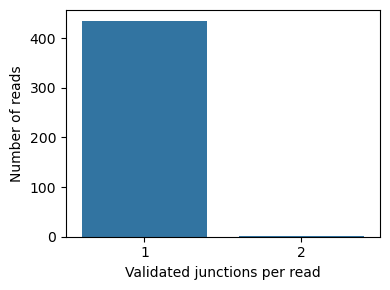

In [29]:
junction_count = (
    junction_summary["n_junctions"]
    .value_counts()
    .sort_index()
    .rename_axis("Junctions")
    .reset_index(name="Reads")
)

display(junction_count)

plt.figure(figsize=(4, 3))

sns.barplot(
    data=junction_count,
    x="Junctions",
    y="Reads",
)

plt.xlabel("Validated junctions per read")
plt.ylabel("Number of reads")

plt.tight_layout()
plt.show()

,read_id,junction_type,transcript_length
0,976d29dc-8666-41fe-9fdf-8ec7dbd57ee9,PolyT,116
1,49fa6fba-28a3-4889-b324-880e6e80b971,PolyA,56
2,92c75ed8-7064-4b94-a91d-bcc31ebf8e10,PolyA,50
3,99dbb03a-c9f8-4565-a6e6-b5e2c06f8e7a,PolyA,51
4,8c8cf732-303a-465c-9255-592edc774e33,PolyA,52


count    439.000000
mean      84.091116
std       63.566819
min       10.000000
25%       53.000000
50%       57.000000
75%      107.000000
max      939.000000
Name: transcript_length, dtype: float64

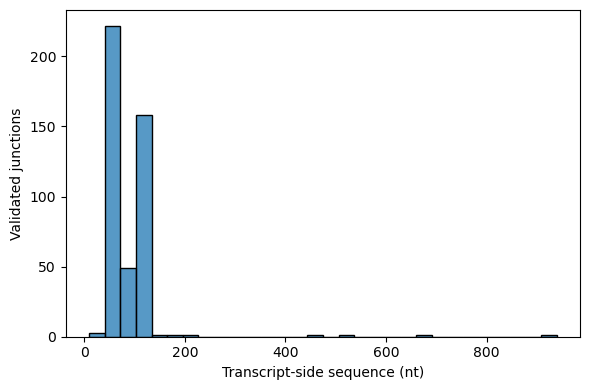

In [34]:
transcript_records = []

for _, row in junction_df.iterrows():

    if row["junction_type"] == "PolyA":

        transcript_length = (
            row["read_length"] - row["adapter_end"]
        )

    else:   # PolyT

        transcript_length = (
            row["adapter_start"]
        )

    transcript_records.append({
        "read_id": row["read_id"],
        "junction_type": row["junction_type"],
        "transcript_length": transcript_length,
    })

transcript_df = pd.DataFrame(transcript_records)

display(transcript_df.head())

display(
    transcript_df["transcript_length"].describe()
)

plt.figure(figsize=(6,4))

sns.histplot(
    transcript_df,
    x="transcript_length",
    bins=30,
)

plt.xlabel("Transcript-side sequence (nt)")
plt.ylabel("Validated junctions")

plt.tight_layout()
plt.show()

,Minimum_transcript_nt,Reads_retained
0,0,439
1,25,438
2,50,411
3,75,212
4,100,189
5,150,6
6,200,5
7,300,4


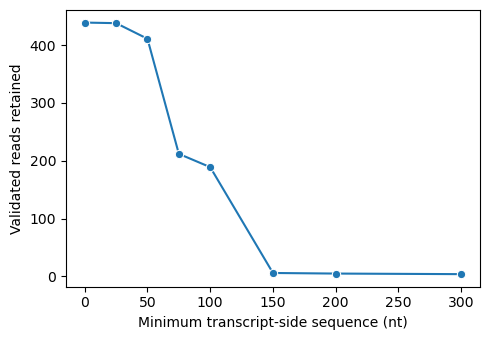

In [36]:
thresholds = [
    0,
    25,
    50,
    75,
    100,
    150,
    200,
    300,
]

threshold_df = pd.DataFrame({
    "Minimum_transcript_nt": thresholds,
    "Reads_retained": [
        (
            transcript_df["transcript_length"] >= t
        ).sum()
        for t in thresholds
    ],
})

display(threshold_df)


plt.figure(figsize=(5,3.5))

sns.lineplot(
    data=threshold_df,
    x="Minimum_transcript_nt",
    y="Reads_retained",
    marker="o",
)

plt.xlabel("Minimum transcript-side sequence (nt)")
plt.ylabel("Validated reads retained")

plt.tight_layout()
plt.show()

,Step,Reads
0,Input reads,1000
1,Validated junction,437
2,Exactly one junction,435
3,Transcript ≥100 nt,189


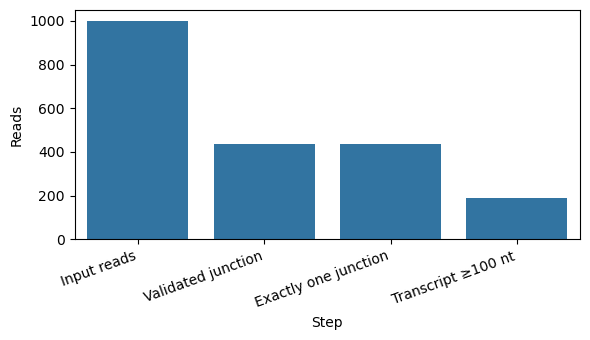

,read_id,sequence,read_length
1,976d29dc-8666-41fe-9fdf-8ec7dbd57ee9,CATGTTATGTCTACTGGTTCCATTATCCCAGCCGATATTCACAGAA...,529
22,dae6fab5-7991-401e-be26-d2978451b813,GTTATGTCCTCTACTTGGTTCGGGTCTTGCAAGCCGATATTCACAG...,571
25,3e185c2f-5c8f-4efa-9ffa-8321e2455190,GGTGTTTATGTCCTCTACTGAGCATTGACAGCCAGATATTGGCAAA...,649
29,1d12c952-13f3-492a-aa34-55a876d752fb,ATGTTGACCCCTTCGTTCGGTTATGCCATGCCGCCCAATTCACAGC...,805
31,9c8fbcfc-e27e-4350-9d81-b5a13116e2e2,ATGTTGTGACGTACTCGTTCGGTTATGCAGCCCCGATATTGGCAAA...,416
37,9dc8047c-18ee-470f-9803-2fae2ac834b2,GTGTTATGTAACTTACTTGGTTCAGTGCCATGACCCGATATTAAGG...,624
38,de580923-fc0c-4590-a9d5-123d6b27f650,ATTTTTATGTTGGCTAAACGGTTATGCCGCCATTTGGCAGGTAACC...,490
42,258011e6-604b-4ede-8beb-c2c782c792b5,GTGTTATGTAGCCCCTTCGTTCAGTTGTGCCGATATGGCAGGTAGC...,340
43,35a22b5b-4780-49b1-b50b-3cfa312fcfb9,GTGTCCTCTGCTTTTGAGTTCTGGCAGCCGGATATTTGGCAGGTGA...,379
44,71f23a51-974a-48a0-b64b-db203ee95935,ATGTTTATAATTTACTGGTTCAGTTAGCCAACAATATCACAGGCTG...,721


In [38]:

summary = []

summary.append({
    "Step": "Input reads",
    "Reads": len(reads_df),
})

summary.append({
    "Step": "Validated junction",
    "Reads": junction_df["read_id"].nunique(),
})

summary.append({
    "Step": "Exactly one junction",
    "Reads": (
        junction_summary["n_junctions"] == 1
    ).sum(),
})

summary.append({
    "Step": "Transcript ≥100 nt",
    "Reads": (
        transcript_df["transcript_length"] >= 100
    ).sum(),
})

filter_summary = pd.DataFrame(summary)

display(filter_summary)

plt.figure(figsize=(6,3.5))

sns.barplot(
    data=filter_summary,
    x="Step",
    y="Reads",
)

plt.xticks(rotation=20, ha="right")

plt.ylabel("Reads")

plt.tight_layout()
plt.show()


kept_reads = (
    transcript_df.loc[
        transcript_df["transcript_length"] >= 100,
        "read_id",
    ]
)

display(
    reads_df.loc[
        reads_df["read_id"].isin(kept_reads)
    ].head(10)
)

Long homopolymers: 718
Reads with long homopolymers: 680


,read_id,Run_type,Run_length,Start,End,Read_length,Relative_position
122,e0dba5d0-6f1c-4d7b-9c82-8ff85f3550ac,PolyT,22,136,158,472,0.288136
305,976d29dc-8666-41fe-9fdf-8ec7dbd57ee9,PolyT,18,136,154,529,0.257089
487,e61fdbfd-bcb3-4c9b-b34b-8e9f6c952c58,PolyT,33,128,161,471,0.271762
781,49fa6fba-28a3-4889-b324-880e6e80b971,PolyA,19,273,292,368,0.741848
1143,92c75ed8-7064-4b94-a91d-bcc31ebf8e10,PolyA,18,488,506,576,0.847222


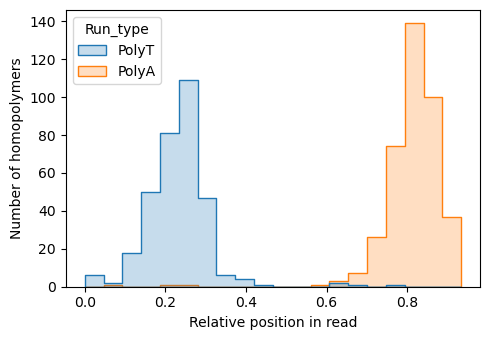

In [39]:
# ============================================
# Long poly(A)/poly(T) positions
# ============================================

position_15_df = position_df.loc[
	position_df["Run_length"] >= 15
].copy()

print("Long homopolymers:", len(position_15_df))
print(
	"Reads with long homopolymers:",
	position_15_df["read_id"].nunique(),
)

display(position_15_df.head())

plt.figure(figsize=(5, 3.5))

sns.histplot(
	data=position_15_df,
	x="Relative_position",
	hue="Run_type",
	bins=20,
	element="step",
	common_norm=False,
)

plt.xlabel("Relative position in read")
plt.ylabel("Number of homopolymers")

plt.tight_layout()
plt.show()

In [40]:
# ============================================
# Full CRTA occurrence in both orientations
# ============================================

crta = "CTTGCGGGCGGCGGACTCTCCTCTGAAGATAGAGCGACAGGCAAG"
anti_crta = korflab.anti(crta)

adapter_records = []

for read_id, seq in zip(
	reads_df["read_id"],
	reads_df["sequence"],
):

	forward = list(re.finditer(crta, seq))
	reverse = list(re.finditer(anti_crta, seq))

	adapter_records.append({
		"read_id": read_id,
		"read_length": len(seq),
		"forward_count": len(forward),
		"reverse_count": len(reverse),
		"adapter_count": len(forward) + len(reverse),
		"forward_positions": [
			(m.start(), m.end())
			for m in forward
		],
		"reverse_positions": [
			(m.start(), m.end())
			for m in reverse
		],
	})

adapter_df = pd.DataFrame(adapter_records)

print(
	"Reads containing forward full CRTA:",
	(adapter_df["forward_count"] > 0).sum(),
)

print(
	"Reads containing reverse-complement full CRTA:",
	(adapter_df["reverse_count"] > 0).sum(),
)

print(
	"Reads containing full CRTA in either orientation:",
	(adapter_df["adapter_count"] > 0).sum(),
)

print(
	"Reads containing multiple full CRTA matches:",
	(adapter_df["adapter_count"] > 1).sum(),
)

display(
	adapter_df.loc[
		adapter_df["adapter_count"] > 0
	].head()
)

Reads containing forward full CRTA: 212
Reads containing reverse-complement full CRTA: 177
Reads containing full CRTA in either orientation: 389
Reads containing multiple full CRTA matches: 0


,read_id,read_length,forward_count,reverse_count,adapter_count,forward_positions,reverse_positions
3,b066f69a-4698-4898-ad43-e1ecb2b4b5ab,489,0,1,1,[],"[(84, 129)]"
4,49fa6fba-28a3-4889-b324-880e6e80b971,368,1,0,1,"[(292, 337)]",[]
6,92c75ed8-7064-4b94-a91d-bcc31ebf8e10,576,1,0,1,"[(506, 551)]",[]
7,99dbb03a-c9f8-4565-a6e6-b5e2c06f8e7a,666,1,0,1,"[(595, 640)]",[]
11,8c8cf732-303a-465c-9255-592edc774e33,678,1,0,1,"[(606, 651)]",[]


,Prefix_length,PolyA_junctions,PolyT_junctions,Total_junctions,Reads_with_junction,Reads_with_one,Reads_with_multiple
0,5,297,277,574,572,570,2
1,7,288,276,564,562,560,2
2,10,268,258,526,524,522,2
3,15,253,224,477,475,473,2
4,20,230,209,439,437,435,2
5,25,209,160,369,368,367,1
6,30,202,137,339,338,337,1
7,40,174,130,304,303,302,1
8,45,168,121,289,289,289,0


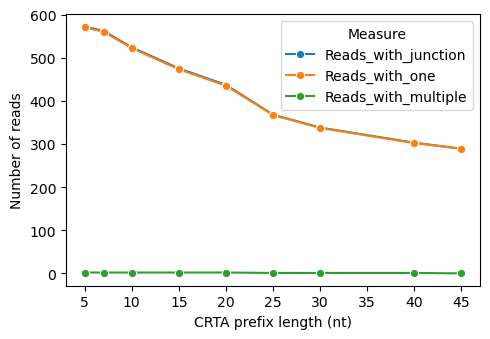

In [41]:
# ============================================
# CRTA prefix comparison using junctions
# ============================================

min_len = 15

crta = "CTTGCGGGCGGCGGACTCTCCTCTGAAGATAGAGCGACAGGCAAG"
prefix_lengths = [5, 7, 10, 15, 20, 25, 30, 40, len(crta)]

apat = re.compile(f"A{{{min_len},}}")
tpat = re.compile(f"T{{{min_len},}}")

prefix_results = []

for prefix_len in prefix_lengths:

	adapter = crta[:prefix_len]

	total_junctions = 0
	reads_with_junction = 0
	reads_with_one = 0
	reads_with_multiple = 0
	polyA_junctions = 0
	polyT_junctions = 0

	for seq in reads_df["sequence"]:

		ams = [
			m for m in apat.finditer(seq)
			if seq[m.end():].startswith(adapter)
		]

		tms = [
			m for m in tpat.finditer(seq)
			if korflab.anti(seq[:m.start()]).startswith(adapter)
		]

		n_junctions = len(ams) + len(tms)

		total_junctions += n_junctions
		polyA_junctions += len(ams)
		polyT_junctions += len(tms)

		if n_junctions > 0:
			reads_with_junction += 1

		if n_junctions == 1:
			reads_with_one += 1

		elif n_junctions > 1:
			reads_with_multiple += 1

	prefix_results.append({
		"Prefix_length": prefix_len,
		"PolyA_junctions": polyA_junctions,
		"PolyT_junctions": polyT_junctions,
		"Total_junctions": total_junctions,
		"Reads_with_junction": reads_with_junction,
		"Reads_with_one": reads_with_one,
		"Reads_with_multiple": reads_with_multiple,
	})

prefix_junction_df = pd.DataFrame(prefix_results)

display(prefix_junction_df)

# ============================================
# CRTA prefix junction comparison
# ============================================

plot_prefix_df = (
	prefix_junction_df[
		[
			"Prefix_length",
			"Reads_with_junction",
			"Reads_with_one",
			"Reads_with_multiple",
		]
	]
	.melt(
		id_vars="Prefix_length",
		var_name="Measure",
		value_name="Reads",
	)
)

plt.figure(figsize=(5, 3.5))

sns.lineplot(
	data=plot_prefix_df,
	x="Prefix_length",
	y="Reads",
	hue="Measure",
	marker="o",
)

plt.xlabel("CRTA prefix length (nt)")
plt.ylabel("Number of reads")

plt.tight_layout()
plt.show()

,read_id,junction_type,transcript_length
0,976d29dc-8666-41fe-9fdf-8ec7dbd57ee9,PolyT,375
1,49fa6fba-28a3-4889-b324-880e6e80b971,PolyA,273
2,92c75ed8-7064-4b94-a91d-bcc31ebf8e10,PolyA,488
3,99dbb03a-c9f8-4565-a6e6-b5e2c06f8e7a,PolyA,563
4,8c8cf732-303a-465c-9255-592edc774e33,PolyA,584


count     439.000000
mean      471.842825
std       182.229722
min       145.000000
25%       347.500000
50%       428.000000
75%       538.000000
max      1580.000000
Name: transcript_length, dtype: float64

Single-junction reads: 435


count     435.000000
mean      471.386207
std       181.286272
min       145.000000
25%       350.000000
50%       428.000000
75%       536.500000
max      1580.000000
Name: transcript_length, dtype: float64

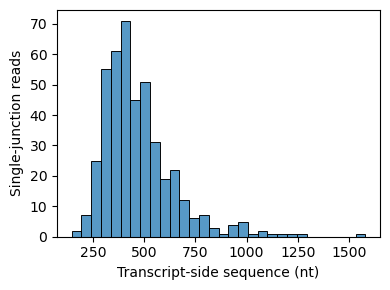

In [44]:
# ============================================
# Transcript-side sequence length
# ============================================

transcript_records = []

for _, row in junction_df.iterrows():

	if row["junction_type"] == "PolyA":
		transcript_length = row["poly_start"]

	else:
		transcript_length = (
			row["read_length"] - row["poly_end"]
		)

	transcript_records.append({
		"read_id": row["read_id"],
		"junction_type": row["junction_type"],
		"transcript_length": transcript_length,
	})

transcript_df = pd.DataFrame(transcript_records)

display(transcript_df.head())
display(transcript_df["transcript_length"].describe())

single_ids = junction_summary.loc[
	junction_summary["n_junctions"] == 1,
	"read_id",
]

single_transcript_df = transcript_df.loc[
	transcript_df["read_id"].isin(single_ids)
].copy()

print(
	"Single-junction reads:",
	single_transcript_df["read_id"].nunique(),
)

display(
	single_transcript_df["transcript_length"].describe()
)

plt.figure(figsize=(4, 3))

sns.histplot(
	data=single_transcript_df,
	x="transcript_length",
	bins=30,
)

plt.xlabel("Transcript-side sequence (nt)")
plt.ylabel("Single-junction reads")

plt.tight_layout()
plt.show()

,Minimum_transcript_nt,Reads_retained
0,0,435
1,25,435
2,50,435
3,75,435
4,100,435
5,150,434
6,200,431
7,300,392


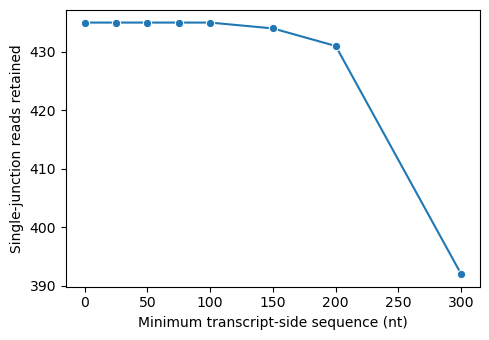

In [45]:
# ============================================
# Transcript-length threshold sensitivity
# ============================================

thresholds = [
	0,
	25,
	50,
	75,
	100,
	150,
	200,
	300,
]

threshold_df = pd.DataFrame({
	"Minimum_transcript_nt": thresholds,
	"Reads_retained": [
		(
			single_transcript_df["transcript_length"] >= threshold
		).sum()
		for threshold in thresholds
	],
})

display(threshold_df)

plt.figure(figsize=(5, 3.5))

sns.lineplot(
	data=threshold_df,
	x="Minimum_transcript_nt",
	y="Reads_retained",
	marker="o",
)

plt.xlabel("Minimum transcript-side sequence (nt)")
plt.ylabel("Single-junction reads retained")

plt.tight_layout()
plt.show()

,Step,Reads
0,Input reads,1000
1,Validated junction,437
2,Exactly one junction,435
3,Transcript ≥100 nt,435


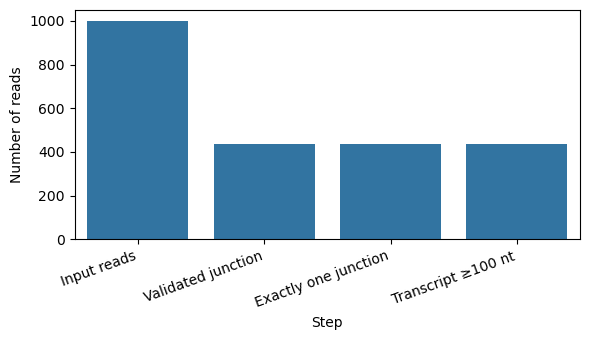

In [46]:
# ============================================
# Corrected filtering summary
# ============================================

filter_summary = pd.DataFrame({
	"Step": [
		"Input reads",
		"Validated junction",
		"Exactly one junction",
		"Transcript ≥100 nt",
	],
	"Reads": [
		len(reads_df),
		junction_df["read_id"].nunique(),
		(single_transcript_df["read_id"].nunique()),
		(
			single_transcript_df["transcript_length"] >= 100
		).sum(),
	],
})

display(filter_summary)

plt.figure(figsize=(6, 3.5))

sns.barplot(
	data=filter_summary,
	x="Step",
	y="Reads",
)

plt.xticks(rotation=20, ha="right")
plt.ylabel("Number of reads")

plt.tight_layout()
plt.show()

,read_id,orientation,window,A_count,non_A_count,A_fraction
0,976d29dc-8666-41fe-9fdf-8ec7dbd57ee9,PolyT,TTTTTTTTTTTTTTTTTTCAAGAAAAACAA,18,12,0.600000
1,b066f69a-4698-4898-ad43-e1ecb2b4b5ab,PolyT,TTTTTTTTTTTCTTTTTTTTTAAGATAATA,22,8,0.733333
2,49fa6fba-28a3-4889-b324-880e6e80b971,PolyA,AACTTTACACGAAAAAAAAAAAAAAAAAAA,23,7,0.766667
3,92c75ed8-7064-4b94-a91d-bcc31ebf8e10,PolyA,ATAATTGGAATTAAAAAAAAAAAAAAAAAA,23,7,0.766667
4,99dbb03a-c9f8-4565-a6e6-b5e2c06f8e7a,PolyA,AAAAAAAAAAAAAAAAAAAAAAAAAAAAAA,30,0,1.000000


,Category,Reads
0,multiple_interruptions,415
1,perfect,97
2,one_interruption,52
3,two_interruptions,33


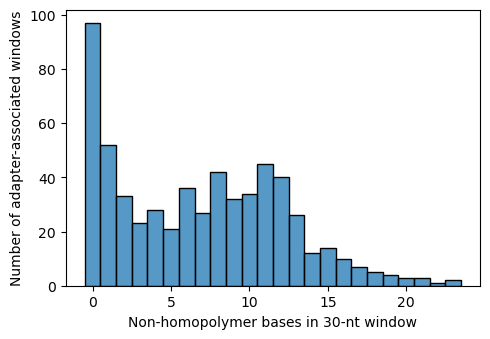

In [49]:
# ============================================
# Interrupted homopolymers near CRTA
# ============================================

crta = "CTTGCGGGCGGCGGACTCTCCTCTGAAGATAGAGCGACAGGCAAG"
adapter_len = 20
adapter = crta[:adapter_len]

window_len = 30

interrupted_records = []

for read_id, seq in zip(
	reads_df["read_id"],
	reads_df["sequence"],
):

	# Forward orientation:
	# transcript | poly(A) | CRTA
	for m in re.finditer(adapter, seq):

		if m.start() < window_len:
			continue

		window = seq[
			m.start() - window_len:
			m.start()
		]

		interrupted_records.append({
			"read_id": read_id,
			"orientation": "PolyA",
			"window": window,
			"A_count": window.count("A"),
			"non_A_count": window_len - window.count("A"),
			"A_fraction": window.count("A") / window_len,
		})

	# Reverse orientation:
	# reverse-CRTA | poly(T) | transcript
	anti_adapter = korflab.anti(adapter)

	for m in re.finditer(anti_adapter, seq):

		if m.end() + window_len > len(seq):
			continue

		window = seq[
			m.end():
			m.end() + window_len
		]

		interrupted_records.append({
			"read_id": read_id,
			"orientation": "PolyT",
			"window": window,
			"A_count": window.count("T"),
			"non_A_count": window_len - window.count("T"),
			"A_fraction": window.count("T") / window_len,
		})

interrupted_df = pd.DataFrame(interrupted_records)

display(interrupted_df.head())

# ============================================
# Classify interruption level
# ============================================

interrupted_df["category"] = "multiple_interruptions"

interrupted_df.loc[
	interrupted_df["non_A_count"] == 0,
	"category",
] = "perfect"

interrupted_df.loc[
	interrupted_df["non_A_count"] == 1,
	"category",
] = "one_interruption"

interrupted_df.loc[
	interrupted_df["non_A_count"] == 2,
	"category",
] = "two_interruptions"

interruption_summary = (
	interrupted_df["category"]
	.value_counts()
	.rename_axis("Category")
	.reset_index(name="Reads")
)

display(interruption_summary)

# ============================================
# Interruption distribution
# ============================================

plt.figure(figsize=(5, 3.5))

sns.histplot(
	data=interrupted_df,
	x="non_A_count",
	bins=range(
		0,
		interrupted_df["non_A_count"].max() + 2,
	),
	discrete=True,
)

plt.xlabel("Non-homopolymer bases in 30-nt window")
plt.ylabel("Number of adapter-associated windows")

plt.tight_layout()
plt.show()

In [50]:
# ============================================
# Representative interrupted windows
# ============================================

examples = (
	interrupted_df
	.sort_values(
		["non_A_count", "read_id"]
	)
	.groupby(
		"category",
		as_index=False,
	)
	.head(5)
)

display(
	examples[
		[
			"read_id",
			"orientation",
			"category",
			"non_A_count",
			"A_fraction",
			"window",
		]
	]
)

,read_id,orientation,category,non_A_count,A_fraction,window
342,0261a82a-e9fc-4132-8e95-de07d5c79887,PolyA,perfect,0,1.000000,AAAAAAAAAAAAAAAAAAAAAAAAAAAAAA
559,034a702b-afd4-473e-b529-686410c71b23,PolyT,perfect,0,1.000000,TTTTTTTTTTTTTTTTTTTTTTTTTTTTTT
554,054fe320-2fd2-46e8-aa01-74546700eccb,PolyT,perfect,0,1.000000,TTTTTTTTTTTTTTTTTTTTTTTTTTTTTT
327,059bc6d9-1146-4b96-9d5b-ac9acc3a9cd5,PolyA,perfect,0,1.000000,AAAAAAAAAAAAAAAAAAAAAAAAAAAAAA
258,062d15b7-9e7b-432c-9b31-6d9ab990ed62,PolyT,perfect,0,1.000000,TTTTTTTTTTTTTTTTTTTTTTTTTTTTTT
335,05e6828d-c4ad-4b5e-80ba-0175820091c9,PolyA,one_interruption,1,0.966667,TAAAAAAAAAAAAAAAAAAAAAAAAAAAAA
438,10f8fe5a-02bf-45d5-818e-fa8b6732a79c,PolyT,one_interruption,1,0.966667,TTTTTTTTTTTTTTTTTTTTTTTTCTTTTT
30,11bb1661-9137-4887-9e61-f1d64c170e51,PolyT,one_interruption,1,0.966667,TTTTTTTTTTTTTTTGTTTTTTTTTTTTTT
114,1362baa6-c705-49b5-b88a-b98d7fb930f0,PolyT,one_interruption,1,0.966667,TTTTTTTTTTTTTTTTTTTTTTTTCTTTTT
459,1f47a022-0772-4c8c-a17e-2a4da231c2ec,PolyA,one_interruption,1,0.966667,CAAAAAAAAAAAAAAAAAAAAAAAAAAAAA


In [51]:
# ============================================
# Interrupted poly(A/T)-CRTA junctions
# ============================================

min_total_A = 15
min_block = 5
adapter_len = 20

crta = "CTTGCGGGCGGCGGACTCTCCTCTGAAGATAGAGCGACAGGCAAG"
adapter = crta[:adapter_len]
anti_adapter = korflab.anti(adapter)

perfect_pat = re.compile(
	f"A{{{min_total_A},}}$"
)

one_interrupt_pat = re.compile(
	f"(A{{{min_block},}})([CGT])(A{{{min_block},}})$"
)

records = []

for read_id, seq in zip(
	reads_df["read_id"],
	reads_df["sequence"],
):

	# Forward orientation:
	# transcript | poly(A) | CRTA
	for am in re.finditer(adapter, seq):

		window = seq[
			max(0, am.start() - 60):
			am.start()
		]

		perfect = perfect_pat.search(window)
		interrupted = one_interrupt_pat.search(window)

		if perfect:
			status = "perfect"
			tail = perfect.group()

		elif interrupted:
			tail = interrupted.group()
			status = "one_interruption"

		else:
			continue

		records.append({
			"read_id": read_id,
			"orientation": "PolyA",
			"status": status,
			"tail": tail,
			"tail_length": len(tail),
			"A_count": tail.count("A"),
			"interruption": (
				None
				if status == "perfect"
				else interrupted.group(2)
			),
		})

	# Reverse orientation:
	# reverse-CRTA | poly(T) | transcript
	for tm in re.finditer(anti_adapter, seq):

		window = seq[
			tm.end():
			min(len(seq), tm.end() + 60)
		]

		window = korflab.anti(window)

		perfect = perfect_pat.search(window)
		interrupted = one_interrupt_pat.search(window)

		if perfect:
			status = "perfect"
			tail = perfect.group()

		elif interrupted:
			tail = interrupted.group()
			status = "one_interruption"

		else:
			continue

		records.append({
			"read_id": read_id,
			"orientation": "PolyT",
			"status": status,
			"tail": tail,
			"tail_length": len(tail),
			"A_count": tail.count("A"),
			"interruption": (
				None
				if status == "perfect"
				else interrupted.group(2)
			),
		})

interrupted_df = pd.DataFrame(records)

display(interrupted_df.head())

,read_id,orientation,status,tail,tail_length,A_count,interruption
0,976d29dc-8666-41fe-9fdf-8ec7dbd57ee9,PolyT,perfect,AAAAAAAAAAAAAAAAAA,18,18,None
1,b066f69a-4698-4898-ad43-e1ecb2b4b5ab,PolyT,one_interruption,AAAAAAAAAGAAAAAAAAAAA,21,20,G
2,49fa6fba-28a3-4889-b324-880e6e80b971,PolyA,perfect,AAAAAAAAAAAAAAAAAAA,19,19,None
3,92c75ed8-7064-4b94-a91d-bcc31ebf8e10,PolyA,perfect,AAAAAAAAAAAAAAAAAA,18,18,None
4,99dbb03a-c9f8-4565-a6e6-b5e2c06f8e7a,PolyA,perfect,AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA,32,32,None


In [52]:
# ============================================
# Perfect and interrupted junction summary
# ============================================

interruption_summary = (
	interrupted_df
	.groupby(
		["status", "orientation"],
		as_index=False,
	)
	.agg(
		Reads=("read_id", "nunique"),
		Junctions=("read_id", "size"),
		Median_tail_length=("tail_length", "median"),
	)
)

display(interruption_summary)

print(
	"Reads with perfect junction:",
	interrupted_df.loc[
		interrupted_df["status"] == "perfect",
		"read_id",
	].nunique(),
)

print(
	"Reads with one interrupted junction:",
	interrupted_df.loc[
		interrupted_df["status"] == "one_interruption",
		"read_id",
	].nunique(),
)

,status,orientation,Reads,Junctions,Median_tail_length
0,one_interruption,PolyA,12,12,26.5
1,one_interruption,PolyT,14,14,23.0
2,perfect,PolyA,230,230,24.5
3,perfect,PolyT,208,209,22.0


Reads with perfect junction: 437
Reads with one interrupted junction: 26


In [53]:
# ============================================
# Interrupted junction examples
# ============================================

display(
	interrupted_df.loc[
		interrupted_df["status"] == "one_interruption",
		[
			"read_id",
			"orientation",
			"tail",
			"tail_length",
			"A_count",
			"interruption",
		],
	]
	.head(20)
)

,read_id,orientation,tail,tail_length,A_count,interruption
1,b066f69a-4698-4898-ad43-e1ecb2b4b5ab,PolyT,AAAAAAAAAGAAAAAAAAAAA,21,20,G
8,e2e3d694-bc55-46ca-b845-ec33c5fafda1,PolyA,AAAAAAAAAAAAAAAAAAAAAAAAAGAAAAAAAAAAAA,38,37,G
23,e62deb1d-b59c-4f8a-9bda-4a69d3750bbc,PolyT,AAAAAAAAAAACAAAAAAAAAAAA,24,23,C
33,2bba7996-d77d-41a9-b039-0c96d1aa1094,PolyT,AAAAAAAGAAAAAAAAAAAA,20,19,G
48,8475c92e-2ea0-47ed-a434-c34a6e584119,PolyA,AAAAAAAAAAAAAAAAGAAAAAAAAA,26,25,G
60,4ac8454e-b20d-4b18-8084-0a92931eb65c,PolyA,AAAAAAAAAAAAGAAAAAAAAAA,23,22,G
86,b1b43a8c-8b3d-4770-806c-f3c63d3a83b2,PolyA,AAAAAGAAAAAAAAAAAAAA,20,19,G
89,a33a4f75-1230-4caa-9027-68fe371fac15,PolyA,AAAAAAAGAAAAAAAAAAAA,20,19,G
120,4577c7af-89a9-4946-a968-27bf7eb70484,PolyA,AAAAAAAAAAATAAAAAAAAAAA,23,22,T
126,70a02c49-b113-493e-a343-d756007554a9,PolyT,AAAAAAAAAAAAACAAAAA,19,18,C


In [55]:
# ============================================
# Strict versus one-interruption junctions
# ============================================

min_len = 15
min_block = 5
adapter_len = 20
window_len = 60

crta = "CTTGCGGGCGGCGGACTCTCCTCTGAAGATAGAGCGACAGGCAAG"
adapter = crta[:adapter_len]
anti_adapter = korflab.anti(adapter)

perfect_pat = re.compile(
	f"A{{{min_len},}}$"
)

interrupt_pat = re.compile(
	f"A{{{min_block},}}([CGT])A{{{min_block},}}$"
)

records = []

for read_id, seq in zip(
	reads_df["read_id"],
	reads_df["sequence"],
):

	# Forward orientation:
	# transcript | poly(A) | CRTA
	for m in re.finditer(adapter, seq):

		window = seq[
			max(0, m.start() - window_len):
			m.start()
		]

		perfect = perfect_pat.search(window)
		interrupted = interrupt_pat.search(window)

		records.append({
			"read_id": read_id,
			"orientation": "PolyA",
			"perfect": perfect is not None,
			"interrupted": interrupted is not None,
			"perfect_tail": (
				perfect.group()
				if perfect else None
			),
			"interrupted_tail": (
				interrupted.group()
				if interrupted else None
			),
			"interruption": (
				interrupted.group(1)
				if interrupted else None
			),
		})

	# Reverse orientation:
	# reverse-CRTA | poly(T) | transcript
	for m in re.finditer(anti_adapter, seq):

		window = seq[
			m.end():
			min(len(seq), m.end() + window_len)
		]

		window = korflab.anti(window)

		perfect = perfect_pat.search(window)
		interrupted = interrupt_pat.search(window)

		records.append({
			"read_id": read_id,
			"orientation": "PolyT",
			"perfect": perfect is not None,
			"interrupted": interrupted is not None,
			"perfect_tail": (
				perfect.group()
				if perfect else None
			),
			"interrupted_tail": (
				interrupted.group()
				if interrupted else None
			),
			"interruption": (
				interrupted.group(1)
				if interrupted else None
			),
		})

interrupt_test_df = pd.DataFrame(records)

interrupt_test_df["category"] = "neither"

interrupt_test_df.loc[
	interrupt_test_df["perfect"],
	"category",
] = "perfect_only"

interrupt_test_df.loc[
	interrupt_test_df["interrupted"],
	"category",
] = "interrupted_only"

interrupt_test_df.loc[
	interrupt_test_df["perfect"]
	&
	interrupt_test_df["interrupted"],
	"category",
] = "both_patterns"

display(
	interrupt_test_df["category"]
	.value_counts()
	.rename_axis("Category")
	.reset_index(name="Junctions")
)

# ============================================
# Junctions rescued by one-interruption rule
# ============================================

rescued_df = interrupt_test_df.loc[
	(~interrupt_test_df["perfect"])
	&
	(interrupt_test_df["interrupted"])
].copy()

print(
	"Junctions rescued by one-interruption rule:",
	len(rescued_df),
)

print(
	"Reads rescued by one-interruption rule:",
	rescued_df["read_id"].nunique(),
)

display(
	rescued_df[
		[
			"read_id",
			"orientation",
			"interrupted_tail",
			"interruption",
		]
	]
	.head(20)
)

,Category,Junctions
0,perfect_only,407
1,neither,132
2,both_patterns,32
3,interrupted_only,26


Junctions rescued by one-interruption rule: 26
Reads rescued by one-interruption rule: 26


,read_id,orientation,interrupted_tail,interruption
1,b066f69a-4698-4898-ad43-e1ecb2b4b5ab,PolyT,AAAAAAAAAGAAAAAAAAAAA,G
9,e2e3d694-bc55-46ca-b845-ec33c5fafda1,PolyA,AAAAAAAAAAAAAAAAAAAAAAAAAGAAAAAAAAAAAA,G
27,e62deb1d-b59c-4f8a-9bda-4a69d3750bbc,PolyT,AAAAAAAAAAACAAAAAAAAAAAA,C
40,2bba7996-d77d-41a9-b039-0c96d1aa1094,PolyT,AAAAAAAGAAAAAAAAAAAA,G
61,8475c92e-2ea0-47ed-a434-c34a6e584119,PolyA,AAAAAAAAAAAAAAAAGAAAAAAAAA,G
74,4ac8454e-b20d-4b18-8084-0a92931eb65c,PolyA,AAAAAAAAAAAAGAAAAAAAAAA,G
106,b1b43a8c-8b3d-4770-806c-f3c63d3a83b2,PolyA,AAAAAGAAAAAAAAAAAAAA,G
109,a33a4f75-1230-4caa-9027-68fe371fac15,PolyA,AAAAAAAGAAAAAAAAAAAA,G
145,4577c7af-89a9-4946-a968-27bf7eb70484,PolyA,AAAAAAAAAAATAAAAAAAAAAA,T
152,70a02c49-b113-493e-a343-d756007554a9,PolyT,AAAAAAAAAAAAACAAAAA,C


In [56]:
# ============================================
# Perfect vs rescued comparison
# ============================================

comparison_df = (
    interrupt_test_df
    .loc[
        interrupt_test_df["category"].isin(
            ["perfect_only", "interrupted_only"]
        )
    ]
    .copy()
)

# read length
comparison_df = comparison_df.merge(
    reads_df[
        [
            "read_id",
            "read_length",
        ]
    ],
    on="read_id",
    how="left",
)

# transcript length
comparison_df = comparison_df.merge(
    single_transcript_df[
        [
            "read_id",
            "transcript_length",
        ]
    ],
    on="read_id",
    how="left",
)

# unified tail length
comparison_df["tail_length"] = comparison_df.apply(
    lambda row:
        len(row["perfect_tail"])
        if pd.notna(row["perfect_tail"])
        else len(row["interrupted_tail"]),
    axis=1,
)

display(comparison_df.head())

,read_id,orientation,perfect,interrupted,perfect_tail,interrupted_tail,interruption,category,read_length,transcript_length,tail_length
0,976d29dc-8666-41fe-9fdf-8ec7dbd57ee9,PolyT,True,False,AAAAAAAAAAAAAAAAAA,None,None,perfect_only,529,375.0,18
1,b066f69a-4698-4898-ad43-e1ecb2b4b5ab,PolyT,False,True,None,AAAAAAAAAGAAAAAAAAAAA,G,interrupted_only,489,NaN,21
2,49fa6fba-28a3-4889-b324-880e6e80b971,PolyA,True,False,AAAAAAAAAAAAAAAAAAA,None,None,perfect_only,368,273.0,19
3,92c75ed8-7064-4b94-a91d-bcc31ebf8e10,PolyA,True,False,AAAAAAAAAAAAAAAAAA,None,None,perfect_only,576,488.0,18
4,99dbb03a-c9f8-4565-a6e6-b5e2c06f8e7a,PolyA,True,False,AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA,None,None,perfect_only,666,563.0,32


In [57]:
# ============================================
# Summary statistics
# ============================================

summary = (
    comparison_df
    .groupby(
        "category"
    )
    .agg(
        Reads=("read_id", "nunique"),
        Mean_read_length=("read_length", "mean"),
        Median_read_length=("read_length", "median"),
        Mean_tail_length=("tail_length", "mean"),
        Median_tail_length=("tail_length", "median"),
        Mean_transcript_length=("transcript_length", "mean"),
        Median_transcript_length=("transcript_length", "median"),
    )
)

display(summary.round(1))

,Reads,Mean_read_length,Median_read_length,Mean_tail_length,Median_tail_length,Mean_transcript_length,Median_transcript_length
category,,,,,,,
interrupted_only,26,561.6,526.0,26.6,25.0,NaN,NaN
perfect_only,406,601.1,558.0,24.7,23.0,473.3,428.0


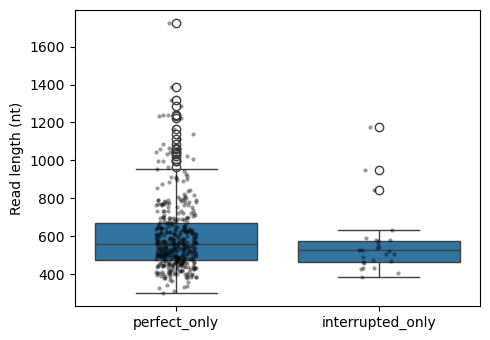

In [58]:
# ============================================
# Read length
# ============================================

plt.figure(figsize=(5,3.5))

sns.boxplot(
    data=comparison_df,
    x="category",
    y="read_length",
)

sns.stripplot(
    data=comparison_df,
    x="category",
    y="read_length",
    color="black",
    alpha=0.4,
    size=3,
)

plt.xlabel("")
plt.ylabel("Read length (nt)")

plt.tight_layout()
plt.show()

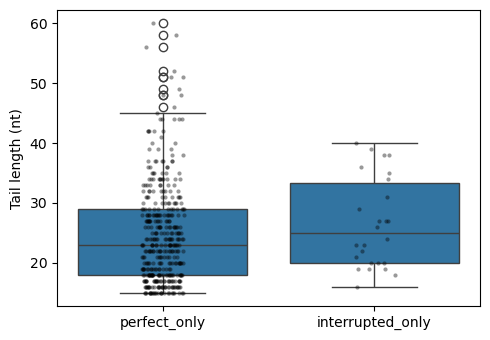

In [59]:
# ============================================
# Tail length
# ============================================

plt.figure(figsize=(5,3.5))

sns.boxplot(
    data=comparison_df,
    x="category",
    y="tail_length",
)

sns.stripplot(
    data=comparison_df,
    x="category",
    y="tail_length",
    color="black",
    alpha=0.4,
    size=3,
)

plt.xlabel("")
plt.ylabel("Tail length (nt)")

plt.tight_layout()
plt.show()

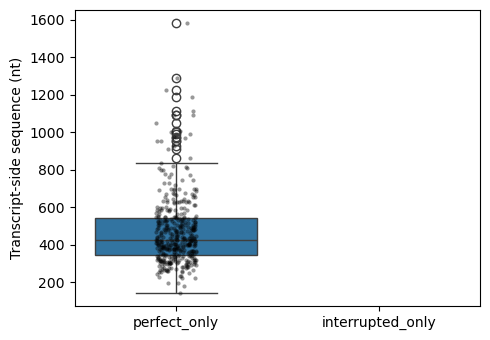

In [60]:
# ============================================
# Transcript length
# ============================================

plt.figure(figsize=(5,3.5))

sns.boxplot(
    data=comparison_df,
    x="category",
    y="transcript_length",
)

sns.stripplot(
    data=comparison_df,
    x="category",
    y="transcript_length",
    color="black",
    alpha=0.4,
    size=3,
)

plt.xlabel("")
plt.ylabel("Transcript-side sequence (nt)")

plt.tight_layout()
plt.show()

,category,orientation,Reads
0,interrupted_only,PolyA,12
1,interrupted_only,PolyT,14
2,perfect_only,PolyA,216
3,perfect_only,PolyT,191


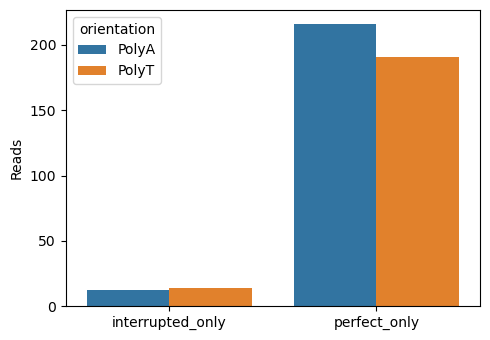

In [61]:
# ============================================
# Orientation
# ============================================

orientation_summary = (
    comparison_df
    .groupby(
        [
            "category",
            "orientation",
        ]
    )
    .size()
    .reset_index(name="Reads")
)

display(orientation_summary)

plt.figure(figsize=(5,3.5))

sns.barplot(
    data=orientation_summary,
    x="category",
    y="Reads",
    hue="orientation",
)

plt.xlabel("")
plt.ylabel("Reads")

plt.tight_layout()
plt.show()

In [62]:
# ============================================
# Strict versus one-interruption junctions
# ============================================

min_len = 15
min_block = 5
adapter_len = 20
window_len = 60

crta = "CTTGCGGGCGGCGGACTCTCCTCTGAAGATAGAGCGACAGGCAAG"
adapter = crta[:adapter_len]
anti_adapter = korflab.anti(adapter)

perfect_pat = re.compile(
	f"A{{{min_len},}}$"
)

interrupt_pat = re.compile(
	f"A{{{min_block},}}([CGT])A{{{min_block},}}$"
)

records = []

for read_id, seq in zip(
	reads_df["read_id"],
	reads_df["sequence"],
):

	# transcript | poly(A) | CRTA
	for m in re.finditer(adapter, seq):

		window = seq[
			max(0, m.start() - window_len):
			m.start()
		]

		perfect = perfect_pat.search(window)
		interrupted = interrupt_pat.search(window)

		if perfect:
			perfect_tail = perfect.group()
			perfect_transcript = m.start() - len(perfect_tail)
		else:
			perfect_tail = None
			perfect_transcript = None

		if interrupted:
			interrupted_tail = interrupted.group()
			interrupted_transcript = (
				m.start() - len(interrupted_tail)
			)
		else:
			interrupted_tail = None
			interrupted_transcript = None

		records.append({
			"read_id": read_id,
			"orientation": "PolyA",
			"read_length": len(seq),
			"perfect": perfect is not None,
			"interrupted": interrupted is not None,
			"perfect_tail": perfect_tail,
			"interrupted_tail": interrupted_tail,
			"perfect_transcript_length": perfect_transcript,
			"interrupted_transcript_length": interrupted_transcript,
			"interruption": (
				interrupted.group(1)
				if interrupted else None
			),
		})

	# reverse-CRTA | poly(T) | transcript
	for m in re.finditer(anti_adapter, seq):

		window = seq[
			m.end():
			min(len(seq), m.end() + window_len)
		]

		window = korflab.anti(window)

		perfect = perfect_pat.search(window)
		interrupted = interrupt_pat.search(window)

		if perfect:
			perfect_tail = perfect.group()
			perfect_transcript = (
				len(seq) - (m.end() + len(perfect_tail))
			)
		else:
			perfect_tail = None
			perfect_transcript = None

		if interrupted:
			interrupted_tail = interrupted.group()
			interrupted_transcript = (
				len(seq) - (m.end() + len(interrupted_tail))
			)
		else:
			interrupted_tail = None
			interrupted_transcript = None

		records.append({
			"read_id": read_id,
			"orientation": "PolyT",
			"read_length": len(seq),
			"perfect": perfect is not None,
			"interrupted": interrupted is not None,
			"perfect_tail": perfect_tail,
			"interrupted_tail": interrupted_tail,
			"perfect_transcript_length": perfect_transcript,
			"interrupted_transcript_length": interrupted_transcript,
			"interruption": (
				interrupted.group(1)
				if interrupted else None
			),
		})

interrupt_test_df = pd.DataFrame(records)

interrupt_test_df["category"] = "neither"

interrupt_test_df.loc[
	interrupt_test_df["perfect"],
	"category",
] = "perfect_only"

interrupt_test_df.loc[
	interrupt_test_df["interrupted"],
	"category",
] = "interrupted_only"

interrupt_test_df.loc[
	interrupt_test_df["perfect"]
	&
	interrupt_test_df["interrupted"],
	"category",
] = "both_patterns"

display(
	interrupt_test_df["category"]
	.value_counts()
	.rename_axis("Category")
	.reset_index(name="Junctions")
)

,Category,Junctions
0,perfect_only,407
1,neither,132
2,both_patterns,32
3,interrupted_only,26


In [65]:
# ============================================
# Perfect-only versus interrupted-only
# ============================================

comparison_df = interrupt_test_df.loc[
	interrupt_test_df["category"].isin(
		["perfect_only", "interrupted_only"]
	)
].copy()

comparison_df["tail"] = np.where(
	comparison_df["category"] == "perfect_only",
	comparison_df["perfect_tail"],
	comparison_df["interrupted_tail"],
)

comparison_df["tail_length"] = (
	comparison_df["tail"].str.len()
)

comparison_df["transcript_length"] = np.where(
	comparison_df["category"] == "perfect_only",
	comparison_df["perfect_transcript_length"],
	comparison_df["interrupted_transcript_length"],
)

display(
	comparison_df[
		[
			"read_id",
			"orientation",
			"category",
			"read_length",
			"tail_length",
			"transcript_length",
			"tail",
		]
	].head()
)

# ============================================
# Multiple records per read
# ============================================

duplicate_records = (
	comparison_df
	.groupby(
		[
			"category",
			"read_id",
		]
	)
	.size()
	.rename("n_records")
	.reset_index()
	.loc[
		lambda x: x["n_records"] > 1
	]
)

display(duplicate_records)

# ============================================
# Inspect duplicated records
# ============================================

duplicate_ids = duplicate_records["read_id"]

display(
	interrupt_test_df.loc[
		interrupt_test_df["read_id"].isin(duplicate_ids),
		[
			"read_id",
			"orientation",
			"category",
			"perfect_tail",
			"interrupted_tail",
			"perfect_transcript_length",
			"interrupted_transcript_length",
		],
	]
)

,read_id,orientation,category,read_length,tail_length,transcript_length,tail
0,976d29dc-8666-41fe-9fdf-8ec7dbd57ee9,PolyT,perfect_only,529,18,375.0,AAAAAAAAAAAAAAAAAA
1,b066f69a-4698-4898-ad43-e1ecb2b4b5ab,PolyT,interrupted_only,489,21,339.0,AAAAAAAAAGAAAAAAAAAAA
2,49fa6fba-28a3-4889-b324-880e6e80b971,PolyA,perfect_only,368,19,273.0,AAAAAAAAAAAAAAAAAAA
3,92c75ed8-7064-4b94-a91d-bcc31ebf8e10,PolyA,perfect_only,576,18,488.0,AAAAAAAAAAAAAAAAAA
4,99dbb03a-c9f8-4565-a6e6-b5e2c06f8e7a,PolyA,perfect_only,666,32,563.0,AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA


,category,read_id,n_records
331,perfect_only,c4fcff48-52ea-4e9a-9dee-b87ab1b67cc4,2


,read_id,orientation,category,perfect_tail,interrupted_tail,perfect_transcript_length,interrupted_transcript_length
242,c4fcff48-52ea-4e9a-9dee-b87ab1b67cc4,PolyT,perfect_only,AAAAAAAAAAAAAAAAAAAAA,None,838.0,NaN
243,c4fcff48-52ea-4e9a-9dee-b87ab1b67cc4,PolyT,perfect_only,AAAAAAAAAAAAAAAAAAAAAAAAAA,None,291.0,NaN


In [67]:
# ============================================
# Keep single-record reads for comparison
# ============================================

record_counts = (
	comparison_df
	.groupby("read_id")
	.size()
)

single_record_ids = record_counts.loc[
	record_counts == 1
].index

comparison_single_df = comparison_df.loc[
	comparison_df["read_id"].isin(single_record_ids)
].copy()

print(
	"Perfect-only single reads:",
	comparison_single_df.loc[
		comparison_single_df["category"] == "perfect_only",
		"read_id",
	].nunique(),
)

print(
	"Interrupted-only single reads:",
	comparison_single_df.loc[
		comparison_single_df["category"] == "interrupted_only",
		"read_id",
	].nunique(),
)

# ============================================
# Perfect versus interrupted summary
# ============================================

comparison_summary = (
	comparison_single_df
	.groupby("category")
	.agg(
		Reads=("read_id", "nunique"),
		Mean_read_length=("read_length", "mean"),
		Median_read_length=("read_length", "median"),
		Mean_tail_length=("tail_length", "mean"),
		Median_tail_length=("tail_length", "median"),
		Mean_transcript_length=("transcript_length", "mean"),
		Median_transcript_length=("transcript_length", "median"),
	)
	.round(1)
)

display(comparison_summary)

Perfect-only single reads: 405
Interrupted-only single reads: 26


,Reads,Mean_read_length,Median_read_length,Mean_tail_length,Median_tail_length,Mean_transcript_length,Median_transcript_length
category,,,,,,,
interrupted_only,26,561.6,526.0,26.6,25.0,432.2,372.0
perfect_only,405,599.1,557.0,24.7,23.0,473.9,429.0
